In [ ]:
#Libraries
import pandas as pd

In [ ]:
#Setup dataset
import pandas as pd

file_path = '/content/open-meteo-37.86N122.21W56m.csv'

df_hourly = pd.read_csv(file_path, skiprows=2, on_bad_lines='skip')
df_hourly.columns = df_hourly.columns.str.strip()

# Convert time column to datetime
df_hourly['time'] = pd.to_datetime(df_hourly['time'], errors='coerce')

# Drop rows where if time conversion doesn't work
df_hourly = df_hourly.dropna(subset=['time'])

df_hourly.set_index('time', inplace=True)

df_hourly.head()


,temperature_2m (°C),cloud_cover (%),pressure_msl (hPa),surface_pressure (hPa),wind_speed_10m (km/h),wind_speed_100m (km/h),wind_direction_10m (°),wind_direction_100m (°),wind_gusts_10m (km/h),direct_radiation (W/m²),relative_humidity_2m (%),sunshine_duration (s)
time,,,,,,,,,,,,
2022-08-16 00:00:00,25.2,0,1009.9,1003.4,10.2,13.5,222,224,31.7,570.0,52.0,3600.00
2022-08-16 01:00:00,24.1,0,1009.6,1003.1,8.8,11.9,192,205,26.6,389.0,55.0,3600.00
2022-08-16 02:00:00,22.2,0,1009.2,1002.7,8.9,10.9,159,197,23.0,196.0,61.0,3600.00
2022-08-16 03:00:00,19.3,0,1009.4,1002.8,11.4,12.4,145,172,22.7,40.0,74.0,2113.75
2022-08-16 04:00:00,18.1,0,1009.6,1003.0,13.4,17.0,149,167,25.9,0.0,80.0,0.00


In [ ]:
#EDA
#Convert to numeric
df_hourly['temperature_2m (°C)'] = pd.to_numeric(df_hourly['temperature_2m (°C)'], errors='coerce')
#Drop any that couldn't be numeric
df_hourly = df_hourly.dropna(subset=['temperature_2m (°C)'])


,temperature_2m (°C),cloud_cover (%),pressure_msl (hPa),surface_pressure (hPa),wind_speed_10m (km/h),wind_speed_100m (km/h),wind_direction_10m (°),wind_direction_100m (°),wind_gusts_10m (km/h),direct_radiation (W/m²),relative_humidity_2m (%),sunshine_duration (s),heatwave
time,,,,,,,,,,,,,
2022-08-16 00:00:00,25.2,0,1009.9,1003.4,10.2,13.5,222,224,31.7,570.0,52.0,3600.00,False
2022-08-16 01:00:00,24.1,0,1009.6,1003.1,8.8,11.9,192,205,26.6,389.0,55.0,3600.00,False
2022-08-16 02:00:00,22.2,0,1009.2,1002.7,8.9,10.9,159,197,23.0,196.0,61.0,3600.00,False
2022-08-16 03:00:00,19.3,0,1009.4,1002.8,11.4,12.4,145,172,22.7,40.0,74.0,2113.75,False
2022-08-16 04:00:00,18.1,0,1009.6,1003.0,13.4,17.0,149,167,25.9,0.0,80.0,0.00,False


## 1. Model the frequency of heatwave occurrence using Poisson to estimate lambda


---



In [ ]:
#Heatwave is anything above 30
heat_threshold = 30
df_hourly['heatwave'] = df_hourly['temperature_2m (°C)'] >= heat_threshold

df_hourly.head()

In [ ]:
#Aggregate heatwaves by day
df_hourly['heatwave'] = df_hourly['heatwave'].astype(bool)

# 1 if any hour is a heatwave, else 0
daily_heatwaves = df_hourly['heatwave'].resample('D').apply(lambda x: x.any()).astype(int)

# Preview
daily_heatwaves.head(10)

,heatwave
time,
2022-08-16,0
2022-08-17,0
2022-08-18,0
2022-08-19,0
2022-08-20,0
2022-08-21,0
2022-08-22,0
2022-08-23,0
2022-08-24,0


In [ ]:
#Estimate poisson
annual_heatwaves = daily_heatwaves.resample('Y').sum()

# Estimate lambda
lambda_poisson = annual_heatwaves.mean()
print("Estimated λ (heatwaves per year):", lambda_poisson)

Estimated λ (heatwaves per year): 12.25


/tmp/ipython-input-3656822078.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_heatwaves = daily_heatwaves.resample('Y').sum()


##2. Simulate number of heatwaves in the next 10 years


---



In [ ]:
#Simulate future heatwaves
import numpy as np

# Simulate for the next 10 years
years = 10
simulated_heatwaves = np.random.poisson(lam=lambda_poisson, size=years)
print("Simulated heatwaves over 10 years:", simulated_heatwaves)
for i, hw in enumerate(simulated_heatwaves, start=1):
    print(f"Year {i}: {hw} heatwaves")

Simulated heatwaves over 10 years: [13 11 11  9 13  8 14  9 16 15]
Year 1: 13 heatwaves
Year 2: 11 heatwaves
Year 3: 11 heatwaves
Year 4: 9 heatwaves
Year 5: 13 heatwaves
Year 6: 8 heatwaves
Year 7: 14 heatwaves
Year 8: 9 heatwaves
Year 9: 16 heatwaves
Year 10: 15 heatwaves


##3. Probability of at least one heatwave in a year


---



In [ ]:
#Probability of at least one heatwave in a year
prob_at_least_one = 1 - np.exp(-lambda_poisson)
print("Probability of at least one heatwave in a year:", prob_at_least_one)

Probability of at least one heatwave in a year: 0.9999952148826079


##4. Which months have the most heatwave days?

/tmp/ipython-input-2458575193.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_heatwaves = daily_heatwaves.resample('M').sum()


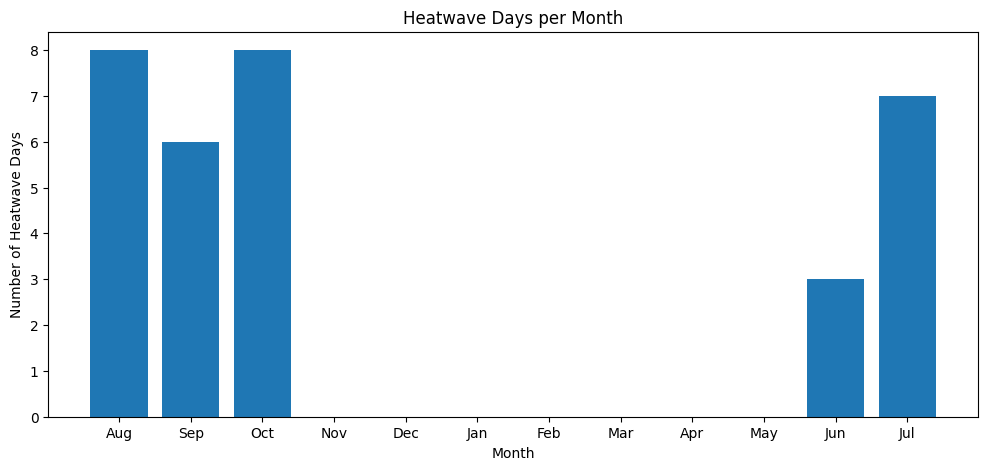

In [ ]:
monthly_heatwaves = daily_heatwaves.resample('M').sum()

months = monthly_heatwaves.index.strftime('%b')

# Plot with month names
plt.figure(figsize=(12,5))
plt.bar(months, monthly_heatwaves)
plt.title('Heatwave Days per Month')
plt.xlabel('Month')
plt.ylabel('Number of Heatwave Days')
plt.show()


##5. Do the same for 3 or more consecutive days of 30 degrees and above

In [ ]:
# daily_heatwaves = df_hourly['heatwave'].resample('D').apply(lambda x: x.any()).astype(int)
consecutive_days_required = 3

#Column for start of consecuritve
streak = (daily_heatwaves != 0).astype(int)
consecutive_heatwaves = (streak.groupby((streak != streak.shift()).cumsum())
                        .transform('cumcount') + 1) * streak

#Identify yes is more than 3 or no
multi_day_heatwave = (consecutive_heatwaves >= consecutive_days_required).astype(int)
multi_day_events = (multi_day_heatwave.diff().fillna(multi_day_heatwave) == 1).astype(int)

print("Total multi-day heatwave events:", multi_day_events.sum())


#Estimate poisson
annual_multi_day = multi_day_events.resample('Y').sum()
lambda_multi_day = annual_multi_day.mean()
print("Estimated λ (multi-day heatwaves/year):", lambda_multi_day)


#Simulate future
years = 10
simulated_multi_day = np.random.poisson(lam=lambda_multi_day, size=years)
print("Simulated multi-day heatwaves over 10 years:", simulated_multi_day)
for i, hw in enumerate(simulated_multi_day, start=1):
    print(f"Year {i}: {hw} heatwaves")



#Prob
prob_at_least_one_multi_day = 1 - np.exp(-lambda_multi_day)
print("Probability of ≥1 multi-day heatwave per year:", prob_at_least_one_multi_day)


Total multi-day heatwave events: 5
Estimated λ (multi-day heatwaves/year): 1.25
Simulated multi-day heatwaves over 10 years: [1 1 4 1 0 1 2 2 1 2]
Year 1: 1 heatwaves
Year 2: 1 heatwaves
Year 3: 4 heatwaves
Year 4: 1 heatwaves
Year 5: 0 heatwaves
Year 6: 1 heatwaves
Year 7: 2 heatwaves
Year 8: 2 heatwaves
Year 9: 1 heatwaves
Year 10: 2 heatwaves
Probability of ≥1 multi-day heatwave per year: 0.7134952031398099


/tmp/ipython-input-1461422825.py:17: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_multi_day = multi_day_events.resample('Y').sum()


Probability of heatwave given humidity > 70%: 0.00


/tmp/ipython-input-1249288019.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_per_bin = df_hourly.groupby('humidity_bin')['heatwave'].mean()


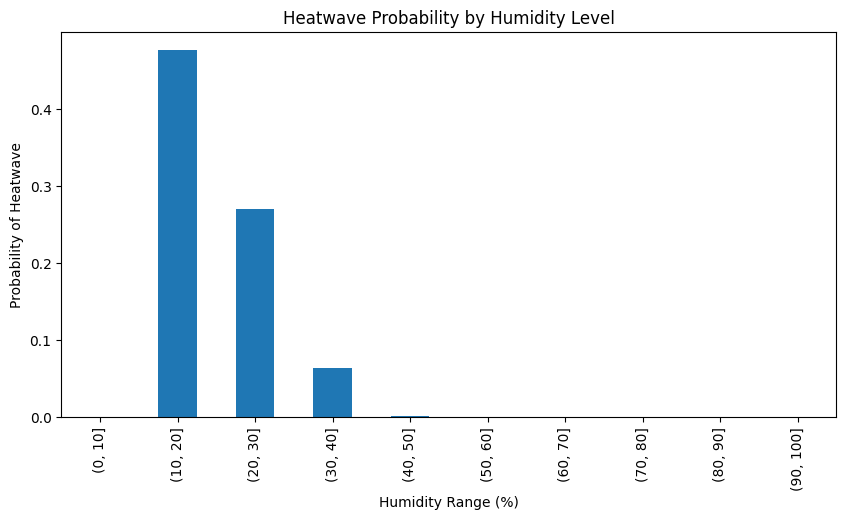

In [ ]:
df_hourly['relative_humidity_2m (%)'] = pd.to_numeric(df_hourly['relative_humidity_2m (%)'], errors='coerce')

#EDA - drop missing
df_hourly = df_hourly.dropna(subset=['relative_humidity_2m (%)', 'temperature_2m (°C)'])

heat_threshold = 30
df_hourly['heatwave'] = df_hourly['temperature_2m (°C)'] >= heat_threshold
#Probability of heatwave given humidity > 70%
humidity_threshold = 70
high_humidity = df_hourly['relative_humidity_2m (%)'] > humidity_threshold

prob_heatwave_high_humidity = df_hourly[high_humidity]['heatwave'].mean()
print(f"Probability of heatwave given humidity > {humidity_threshold}%: {prob_heatwave_high_humidity:.2f}")


import matplotlib.pyplot as plt
#Visualize
humidity_bins = np.arange(0, 101, 10)
df_hourly['humidity_bin'] = pd.cut(df_hourly['relative_humidity_2m (%)'], bins=humidity_bins)
prob_per_bin = df_hourly.groupby('humidity_bin')['heatwave'].mean()

# Plot
prob_per_bin.plot(kind='bar', figsize=(10,5), title='Heatwave Probability by Humidity Level')
plt.ylabel('Probability of Heatwave')
plt.xlabel('Humidity Range (%)')
plt.show()